In [1]:
import numpy as np
from scipy.integrate import quad

In [2]:
def E(a, Omega_m, Omega_r, Omega_l):
    r'''
    Given the scale factor and relevant cosmological parameters, it returns the value(s) of dimensionless Hubble
    parameter :math:`E(a)` which is defined as : 

    .. math::

        E(a) = \sqrt{\Omega_{\Lambda} + \Omega_{m}\, a^{-3} + \Omega_{r}\, a^{-4}}
    
    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float or np.ndarray
        Dimensionless Hubble parameter value(s).

    '''
    return np.sqrt(Omega_l + Omega_m /(a**3) + Omega_r /(a**4))

In [3]:
def H(a, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the scale factor and relevant cosmological parameters, it returns the value(s) of Hubble
    parameter :math:`H(a)` which is given by : 

    .. math::

        H(a) = H_0\,\sqrt{\Omega_{\Lambda} + \Omega_{m}\, a^{-3} + \Omega_{r}\, a^{-4}}
    
    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float or np.ndarray
        Hubble parameter value(s) in units of km/s/Mpc.

    '''

    return H_0*E(a, Omega_m, Omega_r, Omega_l)

In [4]:
def cosmic_age_Euc(a, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the scale factor and relevant cosmological parameters, it computes the cosmic age in an Euclidean universe given by :  

    .. math::

        t = \int_{0}^{a}\,\frac{da'}{a'\,H(a')}
    
    Parameters
    ----------
    a : float 
        Scale factor.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float or np.ndarray
        cosmic age value in yrs.

    '''

    ai = 0 # lower limit of scale factor
    af = a # upper limit of scale factor
    
    return quad(lambda a: 1/ (a * E(a, Omega_m, Omega_r, Omega_l)), ai, af)[0]/(H_0.to(1 / u.yr))

    # (H0.to(1 / u.yr)) is to convert it to yr units


In [5]:
def conformal_time_Euc(a, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the scale factor and relevant cosmological parameters, it computes the conformal time :math:`\eta(a)` in an Euclidean universe given by :  

    .. math::

        \eta(a) = \int_{0}^{a}\,\frac{da'}{a'^2H(a')}
    
    Parameters
    ----------
    a : float 
        Scale factor.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float or np.ndarray
        conformal time value in yrs.

    '''

    ai = 0 # lower limit of scale factor
    af = a # upper limit of scale factor
    
    return quad(lambda a: 1/ (a * a * E(a, Omega_m, Omega_r, Omega_l)), ai, af)[0]/(H_0.to(1 / u.yr))

    # (H0.to(1 / u.yr)) is to convert it to yr units
    

In [6]:
def comov_distance_Euc(z, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the redshift and relevant cosmological parameters, it computes the value of comoving distance
    in an Euclidean universe :math:`\chi(z)` which is given by : 

    .. math::

        \chi^{\rm Euc}(z) = \int_{a(z)}^{1}\,\frac{da'}{a'^2H(a')}, \quad \text{where}, \quad a(z) = \frac{1}{1+z}\\[1em]
    
    Parameters
    ----------
    z : float
        Redshift factor value.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float 
        Comoving distance in units of Mpc.

    '''

    ai = 1/(1+z) # lower limit of scale factor
    af = 1       # upper limit of scale factor
    
    return quad(lambda a: 1/ (a * a * E(a, Omega_m, Omega_r, Omega_l)) , ai, af)[0]/((H_0 / c).to(1 / u.Mpc))

    # ((H_0 / c).to(1 / u.Mpc)) is to due to the natural units convention we followed from the start

In [7]:
def d_A_Euc(z, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the redshift and relevant cosmological parameters, it computes the value of angular diameter distance
    in an Euclidean universe :math:`d_{A}^{\rm Euc}(z)` which is given by : 

    .. math::

        d_{A}^{\rm Euc}(z) = \frac{\chi^{\rm Euc}(z)}{1+z} 
    
    Parameters
    ----------
    z : float
        Redshift factor value.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float 
        Angular diameter distance in units of Mpc.

    '''

    return comov_distance_Euc(z, H_0, Omega_m, Omega_r, Omega_l)/(1+z)
    

In [8]:
def d_L_Euc(z, H_0, Omega_m, Omega_r, Omega_l):
    r'''
    Given the redshift and relevant cosmological parameters, it computes the value of luminosity distance
    in an Euclidean universe :math:`d_{L}^{\rm Euc}(z)` which is given by : 

    .. math::

        d_{L}^{\rm Euc}(z) = ({1+z})\cdot \chi^{\rm Euc}(z)
    
    Parameters
    ----------
    z : float
        Redshift factor value.
    H_0 : float
        Value of Hubble parameter at present in units of km/s/Mpc.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float 
        Luminosity distance in units of Mpc.

    '''

    return comov_distance_Euc(z, H_0, Omega_m, Omega_r, Omega_l)*(1+z)

In [9]:
import astropy.units as u
from astropy.constants import c

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import StrMethodFormatter
plt.style.use('../mplstyle')

#### $\text{Problem 2.1}$

In [10]:
T_0 = 2.726 * u.K
print(T_0.to(u.eV, equivalencies = u.temperature_energy()))

0.00023490850472607756 eV


In [11]:
rho_gamma = np.pi*np.pi*(T_0.to(u.eV, equivalencies = u.temperature_energy()))**4/15
print(rho_gamma)

2.003565053730733e-15 eV4


In [12]:
val = (((1 * u.eV).to(u.g, equivalencies = u.mass_energy()))*(2*np.pi*(1 * u.eV).to(1/u.cm, equivalencies = u.spectral()))**3).value
# val is the conversion factor, 1ev^4 = val * g/cm^3

# define equivalency to convert from ev^4 go g/cm^3
natural_density = u.Equivalency([(u.eV**4, u.g/u.cm**3, lambda x: x * val, lambda x: x / val)])

print(rho_gamma.to(u.g/u.cm**3, equivalencies=natural_density))

4.6485020324177754e-34 g / cm3


In [13]:
H_0 = 100 * u.km / u.s / u.Mpc

print(1/(((H_0.decompose()).to(u.eV, equivalencies = u.spectral())).to(1 / u.cm, equivalencies = u.spectral())))

9.250628667507922e+27 cm


In [14]:
m_PI = 1.2e19  * u.GeV

print(m_PI.to(u.K, equivalencies = u.temperature_energy()))
print(2*np.pi*m_PI.to(1 / u.cm, equivalencies = u.spectral()))
print(2*np.pi*m_PI.to(1 / u.s, equivalencies = u.spectral()))

1.3925421745860096e+32 K
6.081276859387674e+32 1 / cm
1.8231209374543515e+43 1 / s


In [15]:
# define Hubble paramater, Use best fit values
h = 0.6770
H_0 = 100 * h * u.km / u.s / u.Mpc

#### $\text{Problem 2.5}$

In [16]:
cosmic_age_Euc(a = 2.349e-9 , H_0 = H_0, Omega_m = 0.3106, Omega_r = 4.15e-5/(h**2), Omega_l = 0).to(u.s)

<Quantity 132.1482354 s>

In [17]:
cosmic_age_Euc(a = 9.396e-4 , H_0 = H_0, Omega_m = 0.3106, Omega_r = 4.15e-5/(h**2), Omega_l = 0 ).to(u.yr)

<Quantity 388134.73291431 yr>

#### $\text{Problem 2.6}$

In [18]:
conformal_time_Euc(a = 1/1101, H_0 = H_0, Omega_m = 0.3106, Omega_r = 4.15e-5/(h**2), Omega_l = 0)

<Quantity 9.10352021e+08 yr>

#### $\text{Problem 2.7}$

In [19]:
H_0 = 100 * u.km / u.s / u.Mpc # without h form
l   = 5 * u.kpc                # object size 

In [20]:
# Matter dominated case

In [21]:
comov_distance_Euc(z = 0.1, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0)

<Quantity 279.03129518 Mpc>

In [22]:
comov_distance_Euc(z = 1.0, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0)

<Quantity 1756.14355999 Mpc>

In [23]:
(l / d_A_Euc(z = 0.1, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0) * u.rad).to(u.arcsec)

<Quantity 4.06569605 arcsec>

In [24]:
(l / d_A_Euc(z = 1.0, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0) * u.rad).to(u.arcsec)

<Quantity 1.17453271 arcsec>

In [25]:
# Fiducial concordance cosmology 

In [26]:
Omega_m = 0.3106
Omega_l = 0.6894

In [27]:
comov_distance_Euc(z = 0.1, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l)

<Quantity 292.68667521 Mpc>

In [28]:
comov_distance_Euc(z = 1.0, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l)

<Quantity 2298.31275536 Mpc>

In [29]:
(l / d_A_Euc(z = 0.1, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l) * u.rad).to(u.arcsec)

<Quantity 3.87600984 arcsec>

In [30]:
(l / d_A_Euc(z = 1.0, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l) * u.rad).to(u.arcsec)

<Quantity 0.89746187 arcsec>

In [31]:
print("-"*15 + "  Matter Dominated " + "-"*15)

print(f'z = {0.1} : comoving distance  = {comov_distance_Euc(z = 0.1, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0):.4f}' )
print(f'z = {1.0} : comoving distance  = {comov_distance_Euc(z = 1.0, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0):.4f}' )

print(f'z = {0.1} : angular extent     = {(l / d_A_Euc(z = 0.1, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0) * u.rad).to(u.arcsec):.4f}' )
print(f'z = {1.0} : angular extent     = {(l / d_A_Euc(z = 1.0, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0) * u.rad).to(u.arcsec):.4f}' )

print("-"*15 + " Fiducial Cosmology " + "-"*14)

print(f'z = {0.1} : comoving distance  = {comov_distance_Euc(z = 0.1, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l):.4f}' )
print(f'z = {1.0} : comoving distance  = {comov_distance_Euc(z = 1.0, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l):.4f}' )

print(f'z = {0.1} : angular extent     = {(l / d_A_Euc(z = 0.1, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l) * u.rad).to(u.arcsec):.4f}' )
print(f'z = {1.0} : angular extent     = {(l / d_A_Euc(z = 1.0, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l) * u.rad).to(u.arcsec):.4f}' )

print("-"*49)

---------------  Matter Dominated ---------------
z = 0.1 : comoving distance  = 279.0313 Mpc
z = 1.0 : comoving distance  = 1756.1436 Mpc
z = 0.1 : angular extent     = 4.0657 arcsec
z = 1.0 : angular extent     = 1.1745 arcsec
--------------- Fiducial Cosmology --------------
z = 0.1 : comoving distance  = 292.6867 Mpc
z = 1.0 : comoving distance  = 2298.3128 Mpc
z = 0.1 : angular extent     = 3.8760 arcsec
z = 1.0 : angular extent     = 0.8975 arcsec
-------------------------------------------------


#### $\text{Problem 2.10}$

In [32]:
# redshift array 
z = np.logspace(-2, 0, 50)

In [33]:
H_0 = 100 * u.km / u.s / u.Mpc

In [34]:
chi = np.array([comov_distance_Euc(zi, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0).value for zi in z])
d_A = np.array([d_A_Euc(zi, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0).value for zi in z])
d_L = np.array([d_L_Euc(zi, H_0 = H_0, Omega_m = 1, Omega_r = 0, Omega_l = 0).value for zi in z])

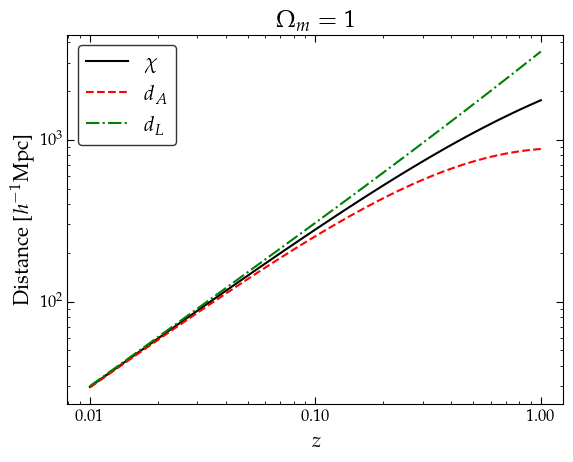

In [35]:
plt.plot(z, chi, 'k'  , lw = 1.5, label = r'$\chi$')
plt.plot(z, d_A, 'r--', lw = 1.5, label = r'$d_A$')
plt.plot(z, d_L, 'g-.', lw = 1.5, label = r'$d_L$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$z$')

# Display numbers normally (no scientific notation)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

plt.ylabel('Distance ' + '[$h^{-1}$' +'Mpc]')
plt.title(r'$ \Omega_{m} = 1$ ', fontsize = 17)
plt.legend(fontsize = 15, fancybox = True, edgecolor = 'k')

plt.savefig("./figs/distance_md.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()

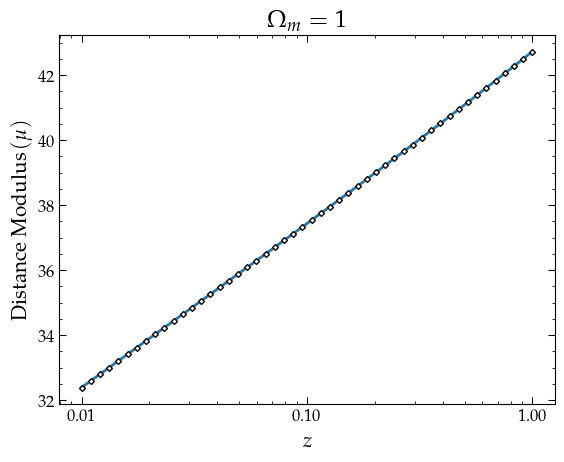

In [36]:
plt.plot(z, 5*np.log10(1e5*d_L), ls = '-', marker = 'D', ms = 3, mfc = 'white', mec = 'k')

plt.xscale('log')
plt.xlabel('$z$')

# Display numbers normally (no scientific notation)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

plt.ylabel('Distance Modulus\,' + r'$(\mu)$')
plt.title(r'$ \Omega_{m} = 1$ ', fontsize = 17)

plt.savefig("./figs/distance_modulus_md.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()

In [37]:
H_0 = 100 * h * u.km / u.s / u.Mpc

Omega_m = 0.3106
Omega_l = 0.6894

chi = np.array([comov_distance_Euc(zi, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l).value for zi in z])
d_A = np.array([d_A_Euc(zi, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l).value for zi in z])
d_L = np.array([d_L_Euc(zi, H_0 = H_0, Omega_m = Omega_m, Omega_r = 0, Omega_l = Omega_l).value for zi in z])

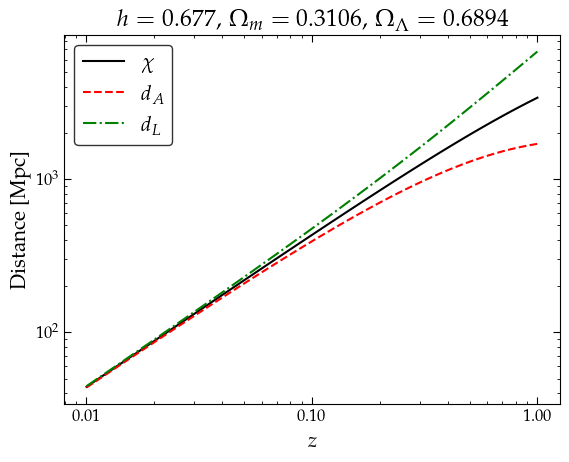

In [38]:
plt.plot(z, chi, 'k'  , lw = 1.5, label = r'$\chi$')
plt.plot(z, d_A, 'r--', lw = 1.5, label = r'$d_A$')
plt.plot(z, d_L, 'g-.', lw = 1.5, label = r'$d_L$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$z$')

# Display numbers normally (no scientific notation)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

plt.ylabel('Distance ' + '[Mpc]')

plt.title(r'$ h = 0.677,\,\Omega_{m} = 0.3106,\,\Omega_{\Lambda} = 0.6894$', fontsize = 17)
plt.legend(fontsize = 15, fancybox = True, edgecolor = 'k')

plt.savefig("./figs/distance_lcdm.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()

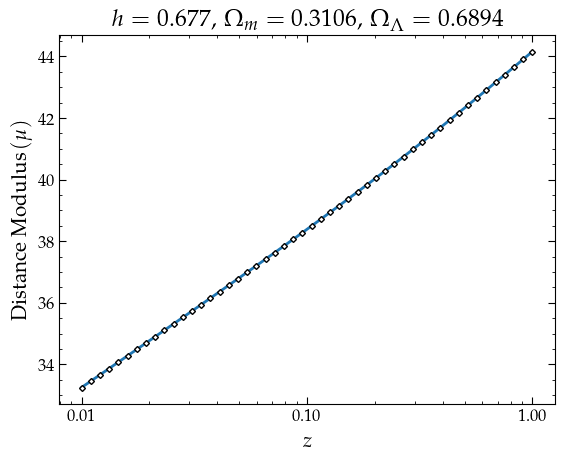

In [39]:
plt.plot(z, 5*np.log10(1e5*d_L), ls = '-', marker = 'D', ms = 3, mfc = 'white', mec = 'k')

plt.xscale('log')
plt.xlabel('$z$')

# Display numbers normally (no scientific notation)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

plt.ylabel('Distance Modulus\,' + r'$(\mu)$')
plt.title(r'$ h = 0.677,\,\Omega_{m} = 0.3106,\,\Omega_{\Lambda} = 0.6894$', fontsize = 17)

plt.savefig("./figs/distance_modulus_lcdm.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()

#### $\text{Problem 2.14}$

In [40]:
def rho_m(a, Omega_m):
    r'''
    Given the scale factor :math:`a` and density parameter of matter (:math:`\Omega_{m}`) at present, it returns 
    the matter energy density :math:`\rho_m(a)` by : 

    .. math::

        \rho_m(a) = \Omega_{m}\, \rho_{\rm cr}\, a^{-3}
        
    Parameters
    ----------
    a : float or np.ndarray 
        Scale factor.
    Omega_m : float
        Density parameter :math:`\Omega_{m}` corresponding to matter at present.

    Returns
    -------
    float or np.ndarray
        Matter energy density.

    '''

    return Omega_m/a**3 # in units of critical density
    

In [41]:
def rho_r(a, Omega_r):
    r'''
    Given the scale factor :math:`a` and density parameter of radiation (:math:`\Omega_{r}`) at present, it returns 
    the radiation energy density :math:`\rho_r(a)` by : 

    .. math::

        \rho_r(a) = \Omega_{r}\, \rho_{\rm cr}\, a^{-4}
        
    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    Omega_r : float
        Density parameter :math:`\Omega_{r}` corresponding to radiation at present.

    Returns
    -------
    float or np.ndarray
        Radiation energy density.

    '''

    return Omega_r/a**4 # in units of critical density
    

In [42]:
def rho_l(a, Omega_l):
    r'''
    Given the scale factor :math:`a` and density parameter of dark energy (:math:`\Omega_{\Lambda}`) at present, it returns 
    the dark energy density :math:`\rho_\Lambda(a)` by : 

    .. math::

        \rho_\Lambda(a) = \Omega_{_\Lambda}\, \rho_{\rm cr}
        
    Parameters
    ----------
    a : float or np.ndarray 
        Scale factor.
    Omega_l : float
        Density parameter :math:`\Omega_{\Lambda}` corresponding to dark energy at present.

    Returns
    -------
    float or np.ndarray
        Dark energy density.

    '''

    return Omega_l*np.ones_like(a) # in units of critical density

In [43]:
a = np.logspace(-5, 0, num = 50)   # scale factor

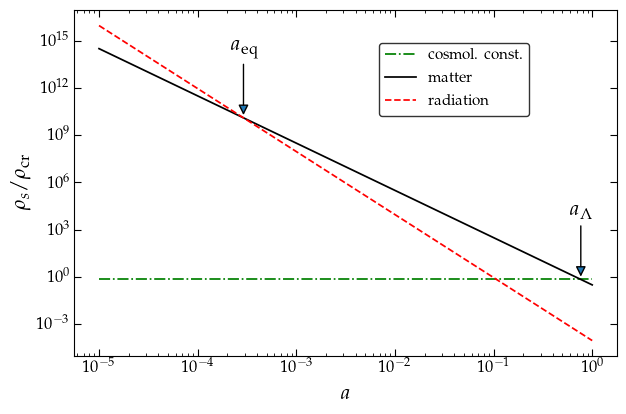

In [44]:
fig = plt.figure(figsize = (7, 4.5))
plt.plot(a, rho_l(a, Omega_l = 0.6894),       'g-.', lw = 1.25, label = 'cosmol. const.') # dark      energy density
plt.plot(a, rho_m(a, Omega_m = 0.3106),       'k'  , lw = 1.25, label = 'matter')         # matter    energy density
plt.plot(a, rho_r(a, Omega_r = 4.15e-5/h**2), 'r--', lw = 1.25, label = 'radiation')      # radiation energy density

plt.xlabel('$a$')
plt.ylabel(r'$\rho_s/\rho_{\rm cr}$')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'center', fontsize = 11, bbox_to_anchor = (.7,.8), fancybox = True, edgecolor = 'k')

a_l = (Omega_m/Omega_l)**(1/3)

a_eq = (4.15e-5/h**2)/0.3106

# annotate the equality scale factors
plt.annotate(r'$a_{\Lambda}$',xy = (a_l, Omega_l), xytext=(0, 50), textcoords = 'offset points', arrowprops = dict(arrowstyle = '-|>'), fontsize = 15, ha = 'center', va = 'center')
plt.annotate(r'$a_{\rm eq}$', xy = (a_eq, rho_m(a_eq, Omega_m = 0.3106)), xytext = (0, 50), textcoords = 'offset points', arrowprops = dict(arrowstyle = '-|>'), fontsize = 15 , ha = 'center', va = 'center')

plt.savefig("./figs/density.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()

In [45]:
# finite mass of neutrino

In [46]:
def T_gamma(a, T0 = 2.7255 * u.K):
    r'''
    Given the present day CMB temperature :math:`T_0`, it computes CMB temperature at given scale factor as :

    .. math::

        T_{\gamma}(a) = \frac{T_{0}}{a}

    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    T0 : float, optional
        Present-day CMB temperature in kelvin. Default is 2.7255 K.
        
    Returns
    -------
    float or np.ndarray
        CMB temperature as a function of scale factor (in kelvin units).
    '''
    return T0/a

In [47]:
def T_nu(a, T0 = 2.7255 * u.K):
    r'''
    Given the present day CMB temperature :math:`T_0`, it computes Neutrino temperature :math:`T_{\nu}` at given scale factor as :

    .. math::

        T_{\nu}(a) = (\frac{4}{11})^{\frac{1}{3}}\,\left(\frac{T_0}{a}\right)
        
    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    T0 : float, optional
        Present-day CMB temperature in kelvin. Default is 2.7255 K.
        
    Returns
    -------
    float or np.ndarray
        Neutrino temperature as a function of scale factor (in kelvin units).
        
    '''
    return T_gamma(a, T0)*(4/11)**(1/3)

In [48]:
def rho_gamma(a, T0 = 2.7255 * u.K):
    r'''
    Given the present day CMB temperature :math:`T_0`, it computes CMB energy density :math:`\rho_{\gamma}` at given scale factor as :

    .. math::

        \rho_{\gamma}(a) = \frac{\pi^2}{15}\,\left(\frac{T_0}{a}\right)^4
        
    Parameters
    ----------
    a : float or np.ndarray
        Scale factor.
    T0 : float, optional
        Present-day CMB temperature in kelvin. Default is 2.7255 K.
        
    Returns
    -------
    float or np.ndarray
        Energy density of CMB as a function of scale factor (in :math:`\text{eV}^4` units).
        
    '''
    return (np.pi**2/15)*(T_gamma(a, T_0).to(u.eV, equivalencies = u.temperature_energy()))**4

In [49]:
def rho_nu(a, m_nu = 0.0 * u.eV, T0 = 2.7255 * u.K):
    r'''
    Given the present day CMB temperature :math:`T_0`, it computes energy density corresponding to a single geneation neutrino
    of mass :math:`m_{\nu_i}` and temperature :math:`T_{\nu}` at given scale factor as :

    .. math::

        \rho_{\nu} = \frac{T_{\nu}^4}{\pi^2}\,\int_{0}^{\infty}\,\frac{x^2dx}{e^x+1}\,\sqrt{x^2 + \qty(\tfrac{m_{\nu}}{T_{\nu}})^2} 
        
    Parameters
    ----------
    a : float 
        Scale factor :math:`a`.
    m_nu : float, optional
        Neutrino mass in eV units. Default is 0.0 eV (assumed massless). 
    T0 : float, optional
        Present-day CMB temperature in kelvin. Default is 2.7255 K.
        
    Returns
    -------
    float 
        Energy density of single generation neutrino as a function of scale factor (in :math:`\text{eV}^4` units).
        
    '''
    arg = m_nu/(T_nu(a, T0).to(u.eV, equivalencies = u.temperature_energy()))

    return ((T_nu(a, T0).to(u.eV, equivalencies = u.temperature_energy()))**4/np.pi**2)*quad(lambda x : x**2*np.sqrt(x**2 + (arg)**2)/(np.exp(x)+1), 0, 80)[0]

In [50]:
T0 = 2.726 * u.K  # CMB temperature at present in kelvin units

m_nu = 0.1 * u.eV # mass of the neutrino in eV units

# scale factor array
a = np.logspace(-5, 0, num = 100)   

In [51]:
# x array m_nu / T_nu

x = m_nu/T_nu(a, T0).to(u.eV, equivalencies = u.temperature_energy())

In [52]:
# CMB energy density at different scale factors
rho_gammaa = rho_gamma(a, T0)     

# Neutrino energy density at different scale factors
rho_nua    = u.Quantity([rho_nu(ai, m_nu, T0) for ai in a])

In [53]:
# y array rho_nu / rho_gamma
y = rho_nua/ rho_gammaa

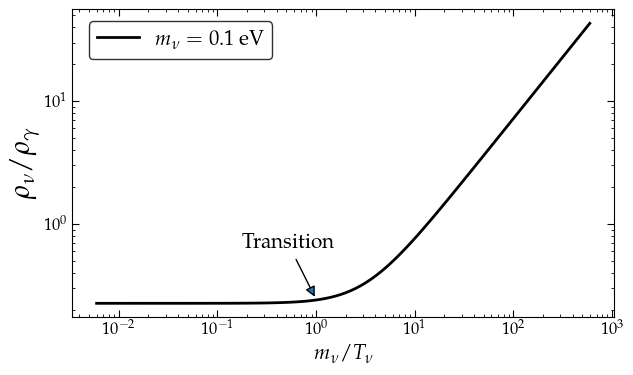

In [54]:
fig = plt.figure(figsize = (7, 4))
plt.plot(x, y, 'k', label=r'$m_{\nu}=0.1\,\mathrm{eV}$')

plt.xlabel(r'$m_{\nu}/T_{\nu}$', fontsize = 15)
plt.ylabel(r'$\rho_{\nu}/\rho_{\gamma}$', fontsize = 20)

plt.xscale('log')
plt.yscale('log')

plt.legend(loc = 'center', fontsize = 15, bbox_to_anchor = (.2,.9), fancybox = True, edgecolor = 'k')
# annotate the equality scale factors
plt.annotate(r'Transition',xy = (1, y[x>1][0]), xytext=(-20, 40), textcoords = 'offset points', arrowprops = dict(arrowstyle = '-|>'), fontsize = 15, ha = 'center', va = 'center')

plt.savefig("./figs/neutrino.pdf", dpi = 700, transparent = True, bbox_inches = "tight", pad_inches = 0.1)
plt.show()